## Multi Agent

### Research Agent
create an agent that performs research using the TavilySearch Tool. this agent is used to gather the required information.

### Chart Generator Agent
create an agent that generates charts using the pythoREPL tool. this agent is used to create a charts.

### Mutli-Agent Graph

In [42]:
!pip install langchain-experimental
!pip install langchain-opentutorial
!pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.3 MB 9.4 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.3 MB 10.3 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.3 MB 8.4 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.3 MB 7.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 6.9 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 6.3 MB/s eta 0:00:01
   -------------------------------------- - 8.9/9.3 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 5.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----- -----------------------


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import os
import operator
import uuid
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal, List, Sequence

from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langchain_experimental.utilities import PythonREPL

In [44]:
load_dotenv(override=True)

True

### LLM Setup (Groq)

In [45]:
def get_groq_llm() -> ChatOpenAI:
    return ChatOpenAI(
        # model="qwen/qwen3-32b",
        model= "llama-3.3-70b-versatile",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.3,
    )

llm = get_groq_llm()

### Tools

In [46]:
tavily_tool= TavilySearchResults(max_results=3, 
                                 search_depth='advanced')

python_repl= PythonREPL()

@tool
def python_repl_tool(code: Annotated[str, "Pure python code only. You MUST save charts as image files."]):
    """Executes Python code. Charts MUST be saved to disk and file path printed."""

    try:
        result= python_repl.run(code)
    except BaseException as e:
        return f"Execution failed: {repr(e)}"

    return f'python executed successfully.\n {result}'

In [47]:
# System Prompt Helper

def make_system_prompt(suffix: str) -> str:
    return(
        "Your are part of multi-agent system.\n"
        "Do not refuse tasks.\n"
        "Follow your role strictly.\n"
        "Do not explain limitations.\n"
        f"{suffix}"
    )

### Research Agent

In [48]:
research_agent_system_prompt= """
You are research agent.

Your job is to gather data needed for chart generation.

STRICT RULES:
1. Use tools like TavilySearch when external data is required.
2. ALWAYS extract or infer numeric values.
3. NEVER refuse due to lack of real-time access.
4. If exact values are unavailable, use best estimates.
5. DO NOT generate charts or code.

OUTPUT FORMAT (MANDATORY):
Return data in a simple, structured, machine-readable format.

Example:
Label: <category or x-axis value>
Value: <numeric value>
Unit: <optional>

Repeat for each data point.
"""

In [49]:
# Research Agent
research_agent= create_react_agent(
    llm, 
    tools= [tavily_tool], 
    prompt= make_system_prompt(research_agent_system_prompt)
)

# Research Agent node
def research_node(state: MessagesState):
    result= research_agent.invoke(state)
    return {'messages': result['messages']}

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9488\1311373685.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent= create_react_agent(


### Chart Generator Agent

In [50]:
chart_generator_system_prompt= """
You are a chart generation agent.

your job is to generate charts based on structured numeric data provided by the research agent.

STRICT RULES:
1. You MUST parse numeric values from the previous message.
2. You MUST decide an appropriate chart type (bar, line, pie) unless specified.
3. You MUST use the `python_repl_tool` to execute your code. DO NOT output raw python code in markdown. Use the tool.
4. You MUST save the chart as a PNG file.
5. You MUST print the saved file path.
6. You MUST NOT refuse or explain limitations.
7. You MUST NOT return FINAL ANSWER until AFTER the tool executes.
8. ALWAYS CALL THE TOOL with proper JSON/tool call format. NEVER write Python code without calling the tool.

Charting rules:
- Use matplotlib
- Label axes clearly
- Add a meaningful title
- Use plt.savefig(), NOT plt.show()

After successful execution, respond ONLY with:
FINAL ANSWER
"""

In [51]:
# Chart Generator agent
chart_generator_agent= create_react_agent(
        llm,
        tools= [python_repl_tool],
        prompt= make_system_prompt(chart_generator_system_prompt)
    )

# Chart Generator node
def chart_generator_node(state: MessagesState):
    result= chart_generator_agent.invoke(state)
    return {'messages': result['messages']}

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9488\1607838592.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_generator_agent= create_react_agent(


In [52]:
# Router
def route(state: MessagesState):
    last_message= state['messages'][-1]
    if 'FINAL ANSWER' in last_message.content:
        return END
    return 'continue'

### Multi-agent workflow

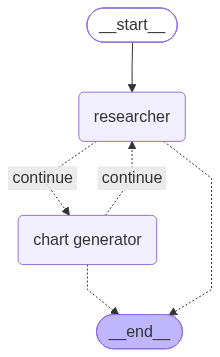

In [53]:
#Build Langgraph
graph= StateGraph(MessagesState)

# Nodes
graph.add_node('researcher', research_node)
graph.add_node('chart generator', chart_generator_node)

#Edges
graph.add_edge(START, 'researcher')
graph.add_conditional_edges('researcher',
                            route,
                            {'continue':'chart generator', END:END})

graph.add_conditional_edges('chart generator',
                            route,
                            {'continue':'researcher', END:END})

app= graph.compile(checkpointer=MemorySaver())
app

### Detailed Workflow

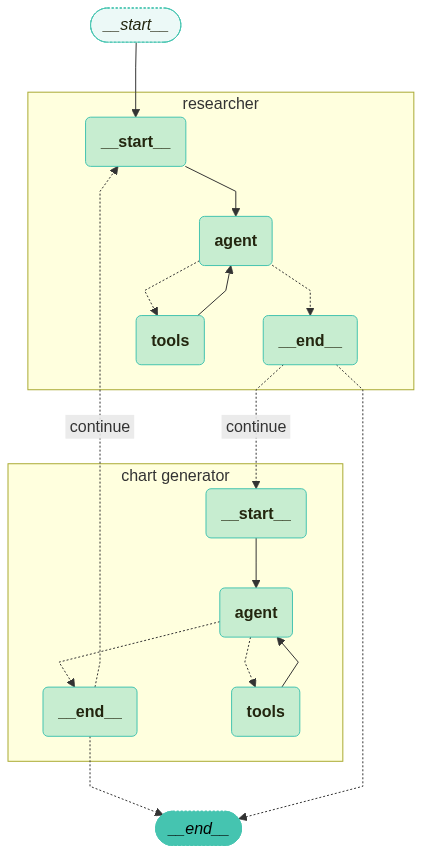

In [54]:
from langchain_opentutorial.graphs import visualize_graph
visualize_graph(app, xray=True)

### Output

#### Example-1

Python REPL can execute arbitrary code. Use with caution.


{'messages': [HumanMessage(content='Compare prices of Oneplus 15R on india online stores Amazon, Flipkart, Meesho & then plot a  bar chart for the same', additional_kwargs={}, response_metadata={}, id='f03d3d9b-aa4e-421c-a318-bf0a2189ed27'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 455, 'total_tokens': 534, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.162707473, 'prompt_time': 0.074139457, 'completion_time': 0.185756034, 'total_time': 0.259895491}, 'model_provider': 'openai', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'id': 'chatcmpl-14f1fafd-6243-4b34-b41e-808869da7451', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fa971-5f59-7ea1-b2d2-52a27575c003-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Oneplus 15R price on Amazon India'}, 'id': 'pf84

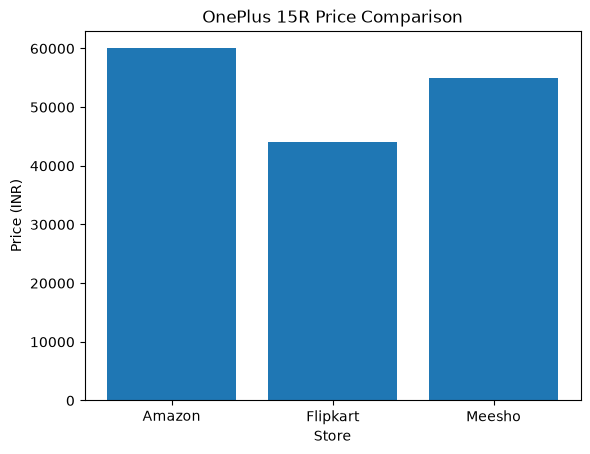

In [27]:
# Invoke Graph
config = RunnableConfig(recursion_limit=10,
                        configurable={"thread_id": str(uuid.uuid4())}
                        )

inputs = {
    "messages": [
        HumanMessage(
            content="Compare prices of Oneplus 15R on india online stores Amazon, Flipkart, Meesho & then plot a  bar chart for the same"
        )
    ]
}

result= app.invoke(inputs, config=config)
result

#### Example-2

{'messages': [HumanMessage(content='do a reserach on gdps of india, usa, and china for the year 2025 & then compare them using a bar chart', additional_kwargs={}, response_metadata={}, id='e4ec224e-8e1c-4b9e-a8b3-d5c3c54f7e1b'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 454, 'total_tokens': 521, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.05242027, 'prompt_time': 0.023348679, 'completion_time': 0.12564166, 'total_time': 0.148990339}, 'model_provider': 'openai', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'id': 'chatcmpl-11a73e7b-fa1e-4022-ab89-08bf5729f43c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fa979-41aa-71a3-a6a7-32a773a0489b-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'India GDP 2025 forecast'}, 'id': 'da4zgdx3n', 'type': 'tool_cal

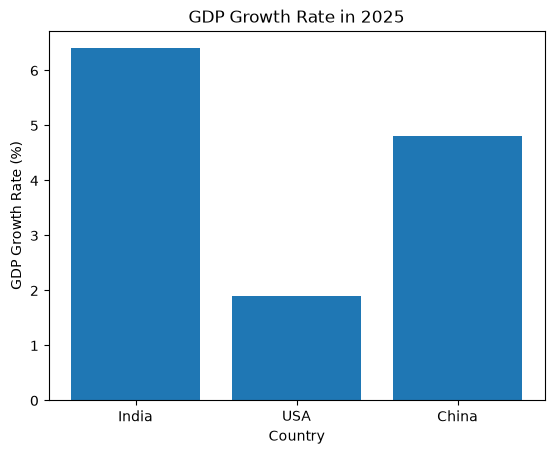

In [55]:
# Invoke Graph
config = RunnableConfig(recursion_limit=10,
                        configurable={"thread_id": str(uuid.uuid4())}
                        )

inputs = {
    "messages": [
        HumanMessage(
            content="do a reserach on gdps of india, usa, and china for the year 2025 & then compare them using a bar chart"
        )
    ]
}

result= app.invoke(inputs, config=config)
result